# Business Understanding

## Abstraksi

- **Tasks:** *forecasting* penjualan tiket bioskop harian.  
- **Input:** penjualan tiket hari ke-1 sampai ke-3 (D1-D3) tiap pasangan film x claster bioskop, ditambah metadata film, kalender, dan harga tiket.  
- **Output:** prediksi total_ticket untuk D4-D10 (7 hari) per pasangan film-klaster.  
- **Metrik:** MASE versi kompetisi.  
- **Sifat Masalah:** *cold-start forecasting*. Film baru hanya punya riwayaat 3 hari, jadi model harus belajar dari pola film-film lain di train.csv.  

## Tujuan Bisnis
Operator bioskop perlu memutuskan hal-hal berikut ketika film baru tayang dan datanya masih sedikit:
- alokasi layar
- jumlah pertunjukan
- kebutuhan oeprasional per lokasi (staf, konsesi, dan sejenisnya)

Tantangannya:
1. Pembukaan film yang kuat tidak menjamin pola yang sama di hari berikutnya.
2. Penjualan awal yang rendah masih bisa naik karena akhir pekan, hari libur, atau word-of-mouth
3. Skala dan karakter tiap klaster berbeda, sehingga perkiraan nasional tidak cukup

**Nilai bisnis yang dicari:** prediksi permintaan 7 hari kedepan di level film-klaster, yang akurat secara relatif terhadap skala masing-masing lokasi, agar keputusan alokasi tidak bias ke klaster besar saja.

## Tujuan Teknis
1. Membangun model yang meminimalkan MASE pada D4-D10.
2. Membangun skema validasi lokal yang meniru kondisi test (D1-D3 sebagai input, D4-D10 sebagai target) dari train.csv.
3. Merekayasa fitur dari: dinamika D1-D3, karakteristik klaster/kota, kalender, harga tiket, dan metadata film.
4. Menjamin reproducibility (seed tetap, pipeline deterministik, kode bisa dijalankan ulang end-to-end).
5. Menghasilkan submission.csv dengan kolom id,total_ticket sebanyak 72.611 baris.

## Rumusan Masalah
**Formulasi:** untuk setiap pasangan p = (film, klaster) dan hari d ∈ {4,…,10}, prediksi y(p,d).

**Metrik (berdasarkan kode):** skala tiap pasangan adalah rata-rata tiket D1-D3 dengan batas bawah 1, dan error tiap baris adalah |y − ŷ| / skala, lalu dirata-ratakan.

Implikasi penting dari metrik ini:

- **Ini bukan MASE klasik.** MASE standar menskalakan dengan error naive forecast, sedangkan di sini skala adalah rata-rata D1-D3. Secara praktis ini seperti MAE pada rasio y/skala.
- **Pasangan berskala kecil sangat berpengaruh.** Klaster dengan rata-rata D1-D3 rendah (atau nol, karena clip(lower=1)) membuat error kecil dalam tiket menjadi error besar dalam skala. Pasangan seperti ini bisa mendominasi skor.
- **Loss yang selaras dengan metrik:** karena metrik berbasis nilai absolut, secara teori prediktor optimal adalah median (bersyarat). Melatih target rasio y/skala dengan loss L1 secara matematis setara dengan metrik. Ini usulan saya dan perlu diuji, tapi argumennya kuat.
- **Banyak nol.** Hari tanpa transaksi dihitung sebagai 0, sehingga distribusi target kemungkinan zero-inflated.
- **Ketidakpastian:** rentang tanggal film uji (apakah di dalam atau setelah periode train) belum saya ketahui. Ini harus dicek di data karena memengaruhi desain validasi.

## Daftar Pertanyaan yang Perlu Dijawab (lewat EDA)
### Struktur data dan validasi
1. Rentang tanggal test_history dan test dibanding train: apakah film uji tayang dalam periode 1 Apr-30 Sep 2025, atau di luarnya?
2. Apakah ada film di test yang juga muncul di train, atau semuanya film baru?
3. Berapa banyak pasangan di test.csv yang tidak punya baris di test_history pada D1-D3 (skala jatuh ke 1)?
4. Bagaimana cara mendefinisikan D1-D3 pseudo di train sehingga meniru aturan "tiga tanggal kalender berturut-turut yang sama untuk seluruh klaster"?
5. Bagaimana judul film dengan penanda format (misalnya 2D/3D/IMAX) memetakan ke movies.csv?
   
### Pola Permintaan
6. Seberapa kuat rasio D4-D10 terhadap rata-rata D1-D3, dan bagaimana variasinya antar film dan klaster?
7. Seberapa besar efek akhir pekan, Jumat, dan hari libur (holidays.csv) terhadap rasio tersebut?
8. Apakah ada tren peluruhan (decay) pasca-pembukaan, dan apakah lajunya bergantung pada genre, rating usia, atau popularitas awal?
9. Bagaimana hubungan total_show dan occupation_rate dengan tiket (dan apakah kolom ini tersedia di test? Sepertinya hanya di history, perlu dicek)?
10. Apakah harga tiket (ticket_prices) berpengaruh setelah mengontrol kota dan hari?
    
### Karakter klaster
11. Apakah klaster bisa dikelompokkan (skala, kota, pola mingguan) agar model berbagi informasi antar klaster?
12. Seberapa sering terjadi nol, dan apakah nol terkait klaster tertentu atau film yang sudah turun layar?
    
### Risiko
13. Apakah ada outlier atau anomali (data rusak, lonjakan ekstrem) yang memengaruhi rasio?
14. Apakah ada kebocoran informasi jika fitur film (misalnya statistik per judul) dihitung dari seluruh train?

## Measurable Outcomes
Angka target absolut tidak bisa saya tetapkan karena belum ada data dan leaderboard. Berikut ukuran yang terukur:

1. **Metrik utama:** MASE validasi lokal lebih rendah daripada baseline.
    - Baseline A: prediksi = rata-rata D1-D3 (rasio konstan 1).
    - Baseline B: baseline A × faktor hari (weekday/Jumat/weekend/holiday).
    - **Target (usulan):** model akhir mengalahkan baseline B secara konsisten di seluruh fold. Besaran perbaikan ditentukan setelah baseline terukur.
2. **Korelasi validasi dan leaderboard:** skor CV dan skor public leaderboard bergerak searah. Jika tidak, skema validasi perlu diperbaiki.
3. **Stabilitas:** deviasi MASE antar fold kecil, dan tidak ada segmen (klaster berskala kecil, film baru) dengan error yang jauh lebih buruk.
4. **Reproducibility:** menjalankan ulang pipeline dengan SEED yang sama menghasilkan prediksi identik atau selisih diabaikan.
5. **Kelengkapan submission:** 72.611 baris, id sesuai template, tanpa NaN dan tanpa nilai negatif.
6. **Interpretabilitas:** minimal ada analisis fitur penting dan analisis error per hari (D4-D10), karena kompetisi menekankan insight yang terstruktur.

# Data Understanding

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import torch
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

# Configuration
SEED = 2026
DATA_DIR = "/kaggle/input/competitions/datajointsxinspire" if os.path.exists("/kaggle/input/competitions/datajointsxinspire") else "."

def set_seed(seed=2026):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True

set_seed(SEED)
print(f"Using DATA_DIR: {DATA_DIR}")
if TORCH_AVAILABLE and torch.cuda.is_available():
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")

Using DATA_DIR: .


In [2]:
files = {
    "train": os.path.join(DATA_DIR, "train.csv"),
    "test_history": os.path.join(DATA_DIR, "test_history.csv"),
    "test": os.path.join(DATA_DIR, "test.csv"),
    "sample_sub": os.path.join(DATA_DIR, "sample_submission.csv"),
    "movies": os.path.join(DATA_DIR, "movies.csv"),
    "holidays": os.path.join(DATA_DIR, "holidays.csv"),
    "ticket_prices": os.path.join(DATA_DIR, "ticket_prices.csv"),
}

dfs = {}
for name, path in files.items():
    dfs[name] = pd.read_csv(path)
    print(f"Loaded {name:12s} | Shape: {dfs[name].shape}")

Loaded train        | Shape: (138959, 7)
Loaded test_history | Shape: (32323, 7)
Loaded test         | Shape: (72611, 5)
Loaded sample_sub   | Shape: (72611, 2)
Loaded movies       | Shape: (397, 7)
Loaded holidays     | Shape: (366, 4)
Loaded ticket_prices | Shape: (207, 3)


In [3]:
def summarize_df(df, name):
    print(f"\n>>> Summary: {name}")
    summary = pd.DataFrame({
        "dtypes": df.dtypes,
        "null_count": df.isnull().sum(),
        "null_pct (%)": (df.isnull().sum() / len(df) * 100).round(2),
        "nunique": df.nunique()
    })
    print(summary)

for name, df in dfs.items():
    summarize_df(df, name)


>>> Summary: train
                  dtypes  null_count  null_pct (%)  nunique
date_show            str           0           0.0      182
cinema_ids           str           0           0.0      117
city_name            str           0           0.0       67
movie_title          str           0           0.0      237
total_ticket       int64           0           0.0     4050
occupation_rate  float64           0           0.0     7866
total_show         int64           0           0.0      196

>>> Summary: test_history
                  dtypes  null_count  null_pct (%)  nunique
date_show            str           0           0.0      120
cinema_ids           str           0           0.0      121
city_name            str           0           0.0       69
movie_title          str           0           0.0      163
total_ticket       int64           0           0.0     1860
occupation_rate  float64           0           0.0     4396
total_show         int64           0           0.0   

In [4]:
# Check date ranges
for name in ["train", "test_history", "test", "holidays"]:
    date_col = "date" if name == "holidays" else "date_show"
    dfs[name][date_col] = pd.to_datetime(dfs[name][date_col])
    min_date = dfs[name][date_col].min().strftime("%Y-%m-%d")
    max_date = dfs[name][date_col].max().strftime("%Y-%m-%d")
    print(f"{name:12s} date range: {min_date} to {max_date}")

# Check entity overlap
train_pairs = set(zip(dfs["train"]["movie_title"], dfs["train"]["cinema_ids"]))
test_pairs = set(zip(dfs["test"]["movie_title"], dfs["test"]["cinema_ids"]))
test_hist_pairs = set(zip(dfs["test_history"]["movie_title"], dfs["test_history"]["cinema_ids"]))

print(f"\nUnique pairs in test: {len(test_pairs)}")
print(f"Test pairs in test_history: {len(test_pairs.intersection(test_hist_pairs))}")
print(f"Test pairs in train history: {len(test_pairs.intersection(train_pairs))}")

train        date range: 2025-04-01 to 2025-09-30
test_history date range: 2025-10-01 to 2026-03-20
test         date range: 2025-10-04 to 2026-03-27
holidays     date range: 2025-04-01 to 2026-04-01

Unique pairs in test: 10373
Test pairs in test_history: 10373
Test pairs in train history: 31


In [5]:
# Calculate D1-D3 scale from test_history
history = dfs["test_history"]
scale_df = history.groupby(["movie_title", "cinema_ids"])["total_ticket"].sum() / 3
scale_df = scale_df.clip(lower=1).reset_index().rename(columns={"total_ticket": "scale"})

print("Scale Summary Statistics (D1-D3 average):")
print(scale_df["scale"].describe())

# Zero sales proportion in train
zero_pct = (dfs["train"]["total_ticket"] == 0).mean() * 100
print(f"\nZero total_ticket proportion in train: {zero_pct:.2f}%")

Scale Summary Statistics (D1-D3 average):
count    11823.000000
mean       204.526262
std        554.230740
min          1.000000
25%         24.000000
50%         73.666667
75%        194.333333
max      24117.333333
Name: scale, dtype: float64

Zero total_ticket proportion in train: 0.00%


# Exploratory Data Analysis (EDA)

## Q1 & Q2 – Rentang tanggal & overlap film test vs train

Apakah film uji tayang dalam periode train (1 Apr–30 Sep 2025), atau di luarnya? Apakah ada film di test yang sudah muncul di train?

In [6]:
# Q1 & Q2 – Date range comparison & film overlap
for name in ['train', 'test_history', 'test']:
    col = 'date_show'
    s = pd.to_datetime(dfs[name][col])
    print(f'{name:14s} | {s.min().date()} → {s.max().date()} | rows: {len(dfs[name]):,}')

train_movies  = set(dfs['train']['movie_title'].unique())
test_movies   = set(dfs['test']['movie_title'].unique())
overlap_films = train_movies & test_movies
print(f'\nFilm unik di train      : {len(train_movies)}')
print(f'Film unik di test       : {len(test_movies)}')
print(f'Film test JUGA di train : {len(overlap_films)}')
print(f'Film test BARU (tidak di train): {len(test_movies - train_movies)}')
if overlap_films:
    print('Contoh overlap:', list(overlap_films)[:5])


train          | 2025-04-01 → 2025-09-30 | rows: 138,959
test_history   | 2025-10-01 → 2026-03-20 | rows: 32,323
test           | 2025-10-04 → 2026-03-27 | rows: 72,611

Film unik di train      : 237
Film unik di test       : 160
Film test JUGA di train : 10
Film test BARU (tidak di train): 150
Contoh overlap: ['DEATH WHISPERER 3', 'THE STRANGERS: CHAPTER 2', 'JANGAN PANGGIL MAMA KAFIR', 'AIR MATA DI UJUNG SAJADAH 2', 'RANGGA & CINTA']


## Q3 – Pasangan test tanpa D1–D3 di test_history (skala jatuh ke 1)

In [7]:
# Q3 – Berapa pasangan test tidak punya riwayat D1-D3?
test_pairs_set  = set(zip(dfs['test']['movie_title'], dfs['test']['cinema_ids']))
hist_pairs_set  = set(zip(dfs['test_history']['movie_title'], dfs['test_history']['cinema_ids']))
missing_hist    = test_pairs_set - hist_pairs_set
pct_missing     = len(missing_hist) / len(test_pairs_set) * 100
print(f'Total pasangan unik di test     : {len(test_pairs_set):,}')
print(f'Pasangan TANPA test_history     : {len(missing_hist):,} ({pct_missing:.1f}%)')
print(f'Pasangan DENGAN test_history    : {len(test_pairs_set) - len(missing_hist):,}')

# Distribusi jumlah hari D1-D3 per pasangan
hist_days = dfs['test_history'].groupby(['movie_title','cinema_ids']).size()
print('\nDistribusi jumlah baris test_history per pasangan:')
print(hist_days.value_counts().sort_index())


Total pasangan unik di test     : 10,373
Pasangan TANPA test_history     : 0 (0.0%)
Pasangan DENGAN test_history    : 10,373

Distribusi jumlah baris test_history per pasangan:
1     777
2    1592
3    9454
Name: count, dtype: int64


## Q4 – Definisi D1–D3 pseudo di train

Verifikasi: apakah D1 = tanggal tayang pertama per (film, klaster), dan tanggal D1-D3 konsisten untuk seluruh klaster dalam satu film?

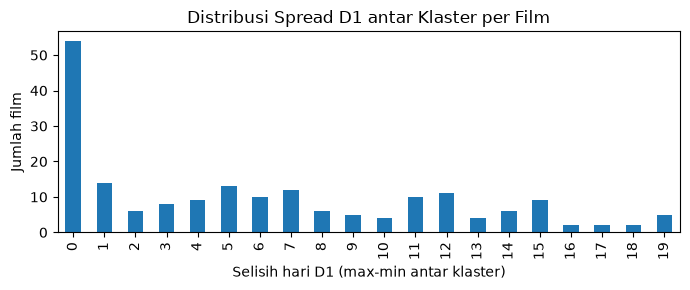

Spread D1 antar klaster (hari), distribusi:
count    237.000000
mean      11.160338
std       14.527867
min        0.000000
25%        1.000000
50%        7.000000
75%       15.000000
max      141.000000
Name: spread_days, dtype: float64

Film dengan D1 berbeda antar klaster (spread > 0):
                                    min        max  spread_days
movie_title                                                    
28 YEARS LATER               2025-06-17 2025-07-01           14
A BIG BOLD BEAUTIFUL JOURNEY 2025-09-18 2025-09-19            1
A MINECRAFT MOVIE            2025-04-04 2025-04-09            5
A MINECRAFT MOVIE (IMAX 2D)  2025-04-08 2025-04-10            2
A WORKING MAN                2025-04-01 2025-04-21           20
AFTERBURN                    2025-09-15 2025-09-27           12
AGAPE THE UNCONDITIONAL LOVE 2025-09-01 2025-09-11           10
AGEN +62                     2025-07-01 2025-07-12           11
AIR MATA DI UJUNG SAJADAH 2  2025-09-26 2025-09-28            2
ANAK M

<string>:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


In [8]:
# Q4 – D1 per (film, klaster) dan konsistensi antar klaster
train = dfs['train'].copy()
train['date_show'] = pd.to_datetime(train['date_show'])
first_dates = train.groupby(['movie_title','cinema_ids'])['date_show'].min().reset_index()
first_dates.columns = ['movie_title','cinema_ids','d1']

# Konsistensi D1 antar klaster per film
d1_per_movie = first_dates.groupby('movie_title')['d1']
d1_range = d1_per_movie.agg(['min','max'])
d1_range['spread_days'] = (d1_range['max'] - d1_range['min']).dt.days
print('Spread D1 antar klaster (hari), distribusi:')
print(d1_range['spread_days'].describe())
print('\nFilm dengan D1 berbeda antar klaster (spread > 0):')
print(d1_range[d1_range['spread_days'] > 0].head(10))

fig, ax = plt.subplots(figsize=(7, 3))
d1_range['spread_days'].value_counts().sort_index().head(20).plot(kind='bar', ax=ax)
ax.set_title('Distribusi Spread D1 antar Klaster per Film')
ax.set_xlabel('Selisih hari D1 (max-min antar klaster)')
ax.set_ylabel('Jumlah film')
plt.tight_layout()
plt.show()


## Q5 – Mapping judul film berformat (2D/3D/IMAX) ke movies.csv

In [9]:
# Q5 – Cek judul berformat vs movies.csv
import re

def clean_title(t):
    return re.sub(r'\s*\((?:IMAX\s*2D|IMAX\s*3D|3D|2D)\)\s*$', '', str(t), flags=re.IGNORECASE).strip()

def extract_format(t):
    u = str(t).upper()
    if 'IMAX 3D' in u: return 'IMAX_3D'
    if 'IMAX' in u: return 'IMAX'
    if '3D' in u: return '3D'
    return 'REGULAR'

train_titles = pd.DataFrame({'raw_title': dfs['train']['movie_title'].unique()})
train_titles['clean'] = train_titles['raw_title'].apply(clean_title)
train_titles['format'] = train_titles['raw_title'].apply(extract_format)
print('Format distribution di train:')
print(train_titles['format'].value_counts())

movies_titles = set(dfs['movies']['original_title'].str.strip())
train_titles['in_movies_csv'] = train_titles['clean'].isin(movies_titles)
match_rate = train_titles['in_movies_csv'].mean() * 100
print(f'\nMatch rate setelah clean: {match_rate:.1f}%')
print('Tidak match (sample 10):')
print(train_titles[~train_titles['in_movies_csv']]['clean'].head(10).tolist())


Format distribution di train:
format
REGULAR    209
IMAX        20
3D           8
Name: count, dtype: int64

Match rate setelah clean: 100.0%
Tidak match (sample 10):
[]


## Q6 – Distribusi rasio D4–D10 terhadap rata-rata D1–D3

Seberapa kuat dan konsisten rasio ini antar film dan klaster?

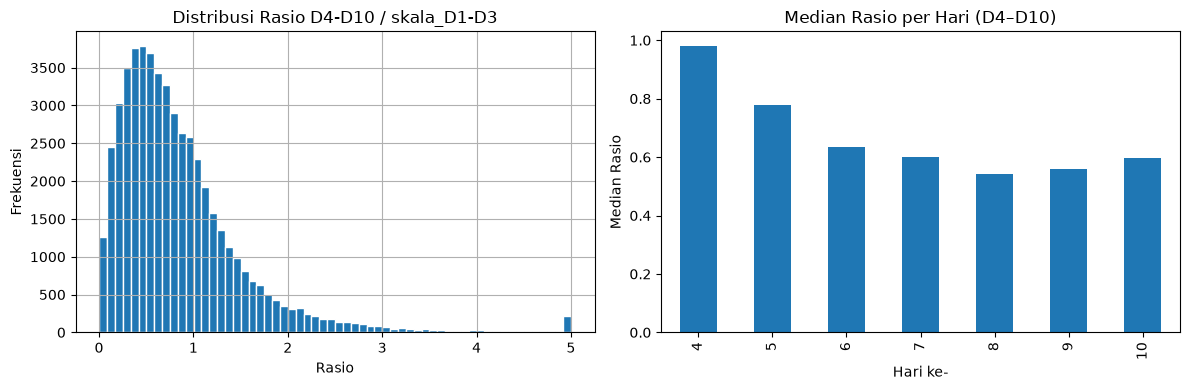

Statistik rasio D4-D10:
count    51921.000
mean         0.862
std          0.813
min          0.002
25%          0.396
50%          0.695
75%          1.098
max         30.924
Name: ratio, dtype: float64


<string>:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


In [10]:
# Q6 – Compute ratio = tickets(Dd) / mean(D1-D3) per (film, klaster, day_index)
train = dfs['train'].copy()
train['date_show'] = pd.to_datetime(train['date_show'])
train = train.sort_values(['movie_title','cinema_ids','date_show'])

records = []
for (movie, cinema), g in train.groupby(['movie_title','cinema_ids']):
    g = g.reset_index(drop=True)
    if len(g) < 4: continue
    scale = max(g.loc[:2, 'total_ticket'].mean(), 1)
    for idx, row in g.iterrows():
        records.append({'movie': movie, 'cinema': cinema,
                        'day_idx': idx + 1, 'ratio': row['total_ticket'] / scale})

ratio_df = pd.DataFrame(records)
d4_10 = ratio_df[ratio_df['day_idx'].between(4, 10)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
d4_10['ratio'].clip(0, 5).hist(bins=60, ax=axes[0], edgecolor='white')
axes[0].set_title('Distribusi Rasio D4-D10 / skala_D1-D3')
axes[0].set_xlabel('Rasio')
axes[0].set_ylabel('Frekuensi')

d4_10.groupby('day_idx')['ratio'].median().plot(kind='bar', ax=axes[1])
axes[1].set_title('Median Rasio per Hari (D4–D10)')
axes[1].set_xlabel('Hari ke-')
axes[1].set_ylabel('Median Rasio')
plt.tight_layout()
plt.show()

print('Statistik rasio D4-D10:')
print(d4_10['ratio'].describe().round(3))


## Q7 – Efek akhir pekan, Jumat, dan hari libur terhadap rasio

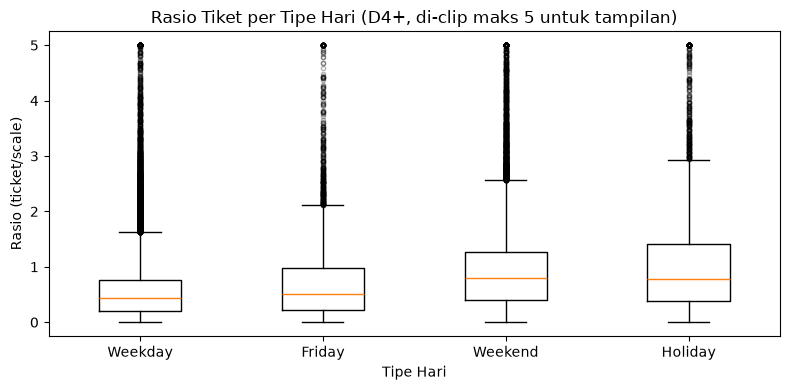

Nilai unik day_tipe    : <StringArray>
['weekday', 'friday', 'weekend']
Length: 3, dtype: str
Nilai unik holiday_tipe: <StringArray>
['holiday', 'normal']
Length: 2, dtype: str
Jumlah baris per tipe hari:
day_type
Weekday    60292
Friday      9528
Weekend    28676
Holiday     4904
Name: count, dtype: int64

Median rasio per tipe hari (tanpa clip):
day_type
Weekday    0.438
Friday     0.501
Weekend    0.795
Holiday    0.780
Name: ratio, dtype: float64


<string>:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


In [11]:
# Q7 – Weekend/Friday/holiday effect on ratio
hol = dfs['holidays'].copy()
hol['date'] = pd.to_datetime(hol['date']).dt.normalize()
for c in ['day_tipe', 'holiday_tipe']:
    hol[c] = hol[c].astype(str).str.strip().str.lower()
print('Nilai unik day_tipe    :', hol['day_tipe'].unique())
print('Nilai unik holiday_tipe:', hol['holiday_tipe'].unique())

train_r = dfs['train'].copy()
train_r['date_show'] = pd.to_datetime(train_r['date_show']).dt.normalize()
train_r = train_r.sort_values(['movie_title', 'cinema_ids', 'date_show'])

# Skala = rata-rata 3 baris pertama per pasangan (konsisten dengan Q6), batas bawah 1
keys = ['movie_title', 'cinema_ids']
train_r['day_idx'] = train_r.groupby(keys).cumcount() + 1
scale = (train_r[train_r['day_idx'] <= 3]
         .groupby(keys)['total_ticket'].mean().clip(lower=1).rename('scale'))
train_r = train_r.join(scale, on=keys)
train_r['ratio'] = train_r['total_ticket'] / train_r['scale']

# Tipe hari dari holidays.csv (bukan dari "tanggal ada di holidays")
train_r = train_r.merge(hol[['date', 'day_tipe', 'holiday_tipe']],
                        left_on='date_show', right_on='date', how='left')
train_r['day_type'] = train_r['day_tipe'].str.capitalize()
train_r.loc[train_r['holiday_tipe'] == 'holiday', 'day_type'] = 'Holiday'

# Hanya D4+ supaya D1-D3 (pembentuk skala) tidak ikut memengaruhi
q7 = train_r[(train_r['day_idx'] >= 4) & train_r['day_type'].notna()]

order = [d for d in ['Weekday', 'Friday', 'Weekend', 'Holiday'] if d in q7['day_type'].unique()]
data = [q7.loc[q7['day_type'] == d, 'ratio'].clip(upper=5).values for d in order]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(data, tick_labels=order, flierprops=dict(marker='.', alpha=0.3))
ax.set_title('Rasio Tiket per Tipe Hari (D4+, di-clip maks 5 untuk tampilan)')
ax.set_xlabel('Tipe Hari')
ax.set_ylabel('Rasio (ticket/scale)')
plt.tight_layout()
plt.show()

print('Jumlah baris per tipe hari:')
print(q7['day_type'].value_counts().reindex(order))
print('\nMedian rasio per tipe hari (tanpa clip):')
print(q7.groupby('day_type')['ratio'].median().reindex(order).round(3))

## Q8 – Tren peluruhan (decay) pasca-pembukaan

Apakah laju decay bergantung pada genre atau popularitas awal?

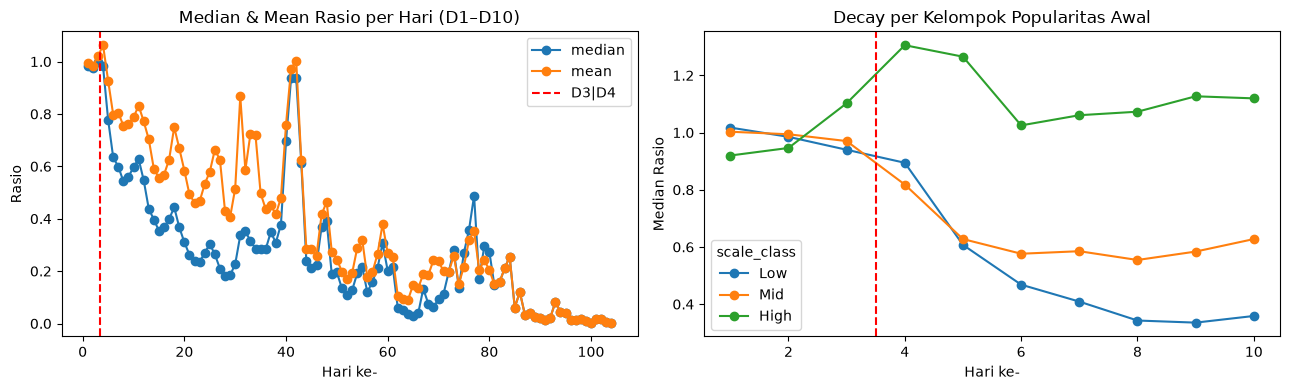

<string>:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


In [12]:
# Q8 – Decay trend by day index
# Use ratio_df from Q6
if 'ratio_df' not in dir():
    raise RuntimeError('Jalankan cell Q6 terlebih dahulu')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall decay
decay = ratio_df.groupby('day_idx')['ratio'].agg(['median','mean'])
decay.plot(ax=axes[0], marker='o')
axes[0].set_title('Median & Mean Rasio per Hari (D1–D10)')
axes[0].set_xlabel('Hari ke-')
axes[0].set_ylabel('Rasio')
axes[0].axvline(3.5, color='red', linestyle='--', label='D3|D4')
axes[0].legend()

# Stratify by early popularity (high vs low scale)
scale_map2 = ratio_df.groupby(['movie','cinema'])['ratio'].transform('first')  # approx
ratio_df['scale_class'] = pd.qcut(
    ratio_df.groupby(['movie','cinema'])['ratio'].transform('mean'),
    q=3, labels=['Low','Mid','High']
)
ratio_df[ratio_df['day_idx'].between(1,10)].groupby(['day_idx','scale_class'])['ratio'].median()\
    .unstack().plot(ax=axes[1], marker='o')
axes[1].set_title('Decay per Kelompok Popularitas Awal')
axes[1].set_xlabel('Hari ke-')
axes[1].set_ylabel('Median Rasio')
axes[1].axvline(3.5, color='red', linestyle='--')

plt.tight_layout()
plt.show()


## Q9 – Ketersediaan `total_show` & `occupation_rate` di test_history dan korelasinya

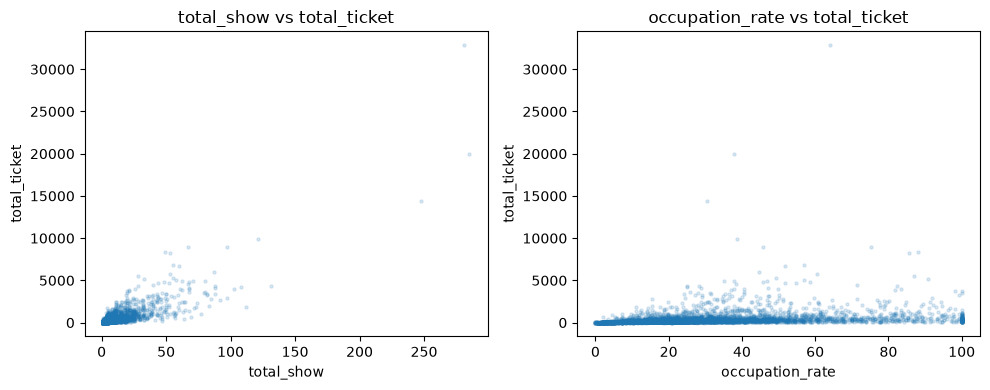

Kolom train: ['date_show', 'cinema_ids', 'city_name', 'movie_title', 'total_ticket', 'occupation_rate', 'total_show']
Kolom test_history: ['date_show', 'cinema_ids', 'city_name', 'movie_title', 'total_ticket', 'occupation_rate', 'total_show']
Kolom test: ['id', 'movie_title', 'cinema_ids', 'city_name', 'date_show']

Korelasi dengan total_ticket:
total_show         0.786288
occupation_rate    0.308982
total_ticket       1.000000
Name: total_ticket, dtype: float64


<string>:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


In [13]:
# Q9 – Check column availability and correlation
print('Kolom train:', dfs['train'].columns.tolist())
print('Kolom test_history:', dfs['test_history'].columns.tolist())
print('Kolom test:', dfs['test'].columns.tolist())

feat_cols_train = [c for c in ['total_show','occupation_rate'] if c in dfs['train'].columns]
if feat_cols_train:
    corr_data = dfs['train'][feat_cols_train + ['total_ticket']].corr()
    print('\nKorelasi dengan total_ticket:')
    print(corr_data['total_ticket'])

    fig, axes = plt.subplots(1, len(feat_cols_train), figsize=(5*len(feat_cols_train), 4))
    if len(feat_cols_train) == 1: axes = [axes]
    for ax, col in zip(axes, feat_cols_train):
        sample = dfs['train'].sample(min(5000, len(dfs['train'])), random_state=42)
        ax.scatter(sample[col], sample['total_ticket'], alpha=0.15, s=5)
        ax.set_xlabel(col)
        ax.set_ylabel('total_ticket')
        ax.set_title(f'{col} vs total_ticket')
    plt.tight_layout()
    plt.show()
else:
    print('total_show / occupation_rate tidak ada di train.')


## Q10 – Pengaruh harga tiket setelah mengontrol kota dan hari

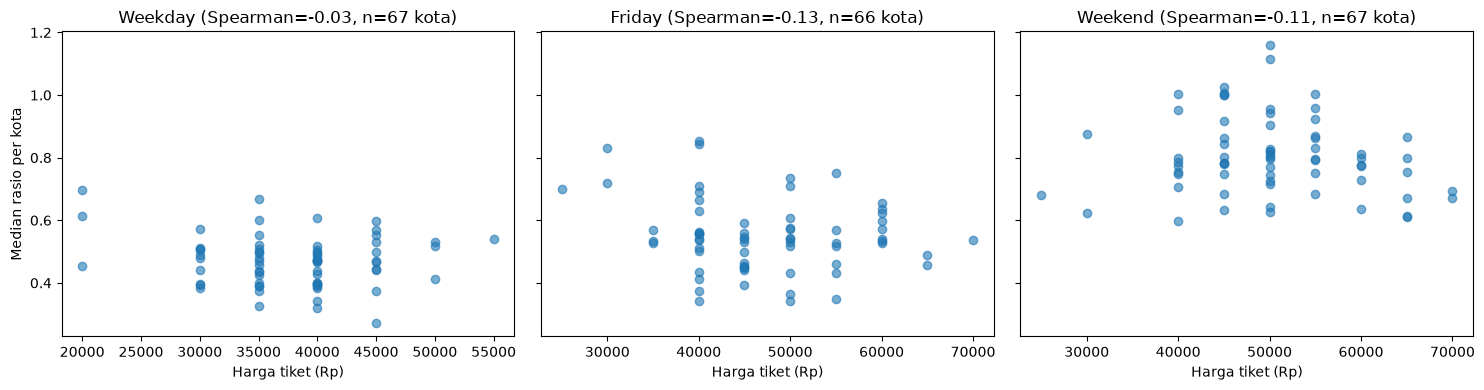

Nilai unik price_day: <StringArray>
['Weekday', 'Friday', 'Weekend']
Length: 3, dtype: str
Duplikat (city, price_day): 0
Baris tanpa harga (kota/tipe hari tidak cocok): 0.00%

Median rasio per kuartil harga (dalam tipe hari yang sama):
price_bin  Q1 (murah)     Q2     Q3  Q4 (mahal)
price_day                                      
Friday          0.509  0.507  0.471       0.554
Weekday         0.440  0.431  0.426       0.510
Weekend         0.805  0.821  0.778       0.734


<string>:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


In [14]:
# Q10 – Ticket price effect on ratio (FIXED)
# Catatan: harga hanya bervariasi per (kota, tipe hari). Di dalam satu kota & tipe hari
# harga konstan, jadi efek harga hanya bisa dilihat ANTAR KOTA pada tipe hari yang sama.

tp = dfs['ticket_prices'].copy()
tp['city_name'] = tp['city_name'].astype(str).str.strip()
tp['price_day'] = tp['price_day'].astype(str).str.strip().str.capitalize()
print('Nilai unik price_day:', tp['price_day'].unique())
print('Duplikat (city, price_day):', tp.duplicated(['city_name', 'price_day']).sum())

hol = dfs['holidays'].copy()
hol['date'] = pd.to_datetime(hol['date']).dt.normalize()
for c in ['day_tipe', 'holiday_tipe']:
    hol[c] = hol[c].astype(str).str.strip().str.lower()

df = dfs['train'].copy()
df['city_name'] = df['city_name'].astype(str).str.strip()
df['date_show'] = pd.to_datetime(df['date_show']).dt.normalize()
df = df.sort_values(['movie_title', 'cinema_ids', 'date_show'])

keys = ['movie_title', 'cinema_ids']
df['day_idx'] = df.groupby(keys).cumcount() + 1
scale = (df[df['day_idx'] <= 3].groupby(keys)['total_ticket']
         .mean().clip(lower=1).rename('scale'))
df = df.join(scale, on=keys)
df['ratio'] = df['total_ticket'] / df['scale']

# Tipe hari -> kategori harga (Weekday/Friday/Weekend)
df = df.merge(hol[['date', 'day_tipe', 'holiday_tipe']],
              left_on='date_show', right_on='date', how='left')
df['price_day'] = df['day_tipe'].str.capitalize()
# ASUMSI (verifikasi): hari libur dikenai tarif Weekend
df.loc[df['holiday_tipe'] == 'holiday', 'price_day'] = 'Weekend'

# Merge harga pada (kota, tipe hari) -> tidak menggandakan baris
n_before = len(df)
df = df.merge(tp[['city_name', 'price_day', 'ceil']],
              on=['city_name', 'price_day'], how='left')
assert len(df) == n_before, 'Merge menggandakan baris, cek duplikat di ticket_prices'
print(f'Baris tanpa harga (kota/tipe hari tidak cocok): {df["ceil"].isna().mean()*100:.2f}%')

q10 = df[(df['day_idx'] >= 4) & df['ceil'].notna()].copy()

# 1) Median rasio per kuartil harga, dipisah per tipe hari
q10['price_bin'] = q10.groupby('price_day')['ceil'].transform(
    lambda s: pd.qcut(s, q=4, labels=['Q1 (murah)', 'Q2', 'Q3', 'Q4 (mahal)'], duplicates='drop')
    if s.nunique() >= 4 else np.nan)
print('\nMedian rasio per kuartil harga (dalam tipe hari yang sama):')
print(q10.pivot_table(index='price_day', columns='price_bin', values='ratio',
                      aggfunc='median', observed=True).round(3))

# 2) Level kota: harga vs median rasio, per tipe hari
city = (q10.groupby(['city_name', 'price_day'])
        .agg(price=('ceil', 'first'), med_ratio=('ratio', 'median'), n=('ratio', 'size'))
        .reset_index())
city = city[city['n'] >= 30]  # buang kota dengan sampel sangat kecil

days = [d for d in ['Weekday', 'Friday', 'Weekend'] if d in city['price_day'].unique()]
fig, axes = plt.subplots(1, len(days), figsize=(5 * len(days), 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, d in zip(axes, days):
    c = city[city['price_day'] == d]
    ax.scatter(c['price'], c['med_ratio'], alpha=0.6)
    rho = c['price'].corr(c['med_ratio'], method='spearman')
    ax.set_title(f'{d} (Spearman={rho:.2f}, n={len(c)} kota)')
    ax.set_xlabel('Harga tiket (Rp)')
axes[0].set_ylabel('Median rasio per kota')
plt.tight_layout()
plt.show()

## Q11 – Pengelompokan klaster berdasarkan skala, kota, dan pola mingguan

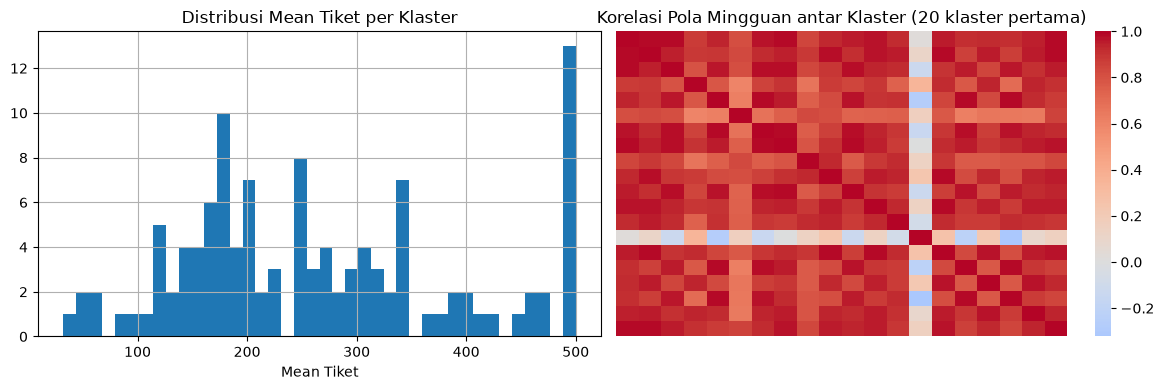

Total klaster: 117
       mean_tickets  median_tickets   n_rows  n_movies
count        117.00          117.00   117.00    117.00
mean         283.61          156.50  1187.68    111.46
std          183.05           65.57   549.20     39.61
min           32.25           26.00   212.00     21.00
25%          174.35          117.00   821.00     85.00
50%          249.13          150.00  1123.00    111.00
75%          342.68          192.00  1477.00    136.00
max         1422.58          475.00  2899.00    213.00


<string>:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


In [15]:
# Q11 – Cluster characterization
train_cl = dfs['train'].copy()
train_cl['date_show'] = pd.to_datetime(train_cl['date_show'])
train_cl['dow'] = train_cl['date_show'].dt.dayofweek

cluster_stats = train_cl.groupby('cinema_ids').agg(
    mean_tickets=('total_ticket','mean'),
    median_tickets=('total_ticket','median'),
    n_rows=('total_ticket','count'),
    n_movies=('movie_title','nunique'),
).reset_index()

print(f'Total klaster: {len(cluster_stats)}')
print(cluster_stats.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cluster_stats['mean_tickets'].clip(0,500).hist(bins=40, ax=axes[0])
axes[0].set_title('Distribusi Mean Tiket per Klaster')
axes[0].set_xlabel('Mean Tiket')

# Weekly pattern per cluster (avg per dow)
dow_pattern = train_cl.groupby(['cinema_ids','dow'])['total_ticket'].mean().unstack()
dow_corr = dow_pattern.T.corr()
sns.heatmap(dow_corr.values[:20,:20], ax=axes[1], cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False)
axes[1].set_title('Korelasi Pola Mingguan antar Klaster (20 klaster pertama)')
plt.tight_layout()
plt.show()


## Q12 – Frekuensi nol: apakah terkait klaster tertentu atau film yang sudah turun layar?

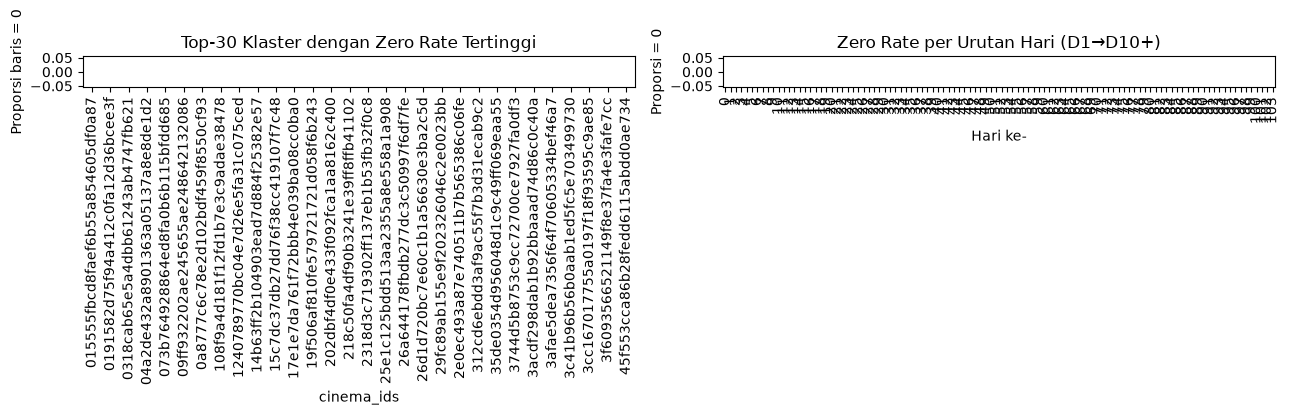

Overall zero rate: 0.0%


<string>:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


In [16]:
# Q12 – Zero ticket analysis
train_z = dfs['train'].copy()
train_z['date_show'] = pd.to_datetime(train_z['date_show'])
train_z['is_zero'] = train_z['total_ticket'] == 0

zero_by_cluster = train_z.groupby('cinema_ids')['is_zero'].mean().sort_values(ascending=False)
zero_by_day = train_z.sort_values(['movie_title','cinema_ids','date_show'])\
    .groupby(['movie_title','cinema_ids']).apply(
        lambda g: g.reset_index(drop=True)['is_zero']
    ).groupby(level=2).mean()  # day_index level

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
zero_by_cluster.head(30).plot(kind='bar', ax=axes[0])
axes[0].set_title('Top-30 Klaster dengan Zero Rate Tertinggi')
axes[0].set_xlabel('cinema_ids')
axes[0].set_ylabel('Proporsi baris = 0')
axes[0].tick_params(axis='x', rotation=90)

zero_by_day.plot(kind='bar', ax=axes[1])
axes[1].set_title('Zero Rate per Urutan Hari (D1→D10+)')
axes[1].set_xlabel('Hari ke-')
axes[1].set_ylabel('Proporsi = 0')

plt.tight_layout()
plt.show()

print(f"Overall zero rate: {train_z['is_zero'].mean()*100:.1f}%")


## Q13 – Outlier dan anomali: data rusak atau lonjakan ekstrem

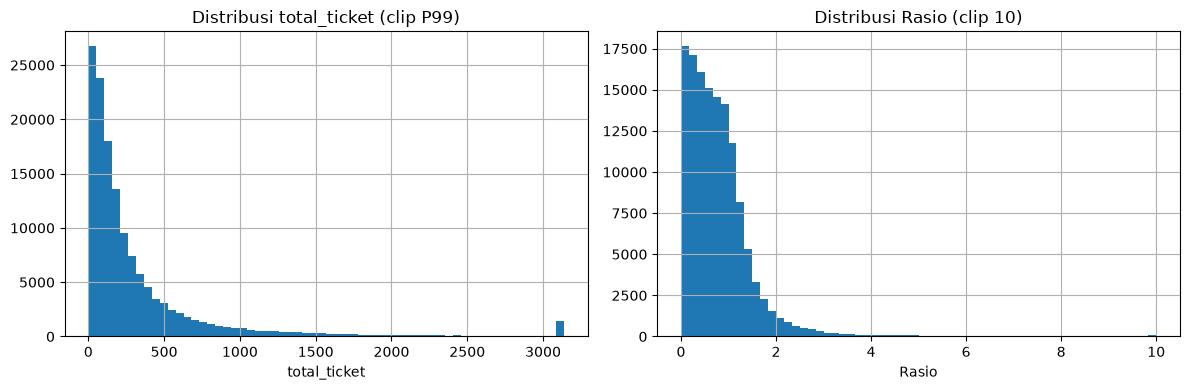

Max: 32,845
P99: 3,136  |  P99.9: 8,628

Rasio > 5: 471 baris (0.35%)
Negative total_ticket: 0
Null total_ticket    : 0


<string>:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


In [17]:
# Q13 – Outlier detection on total_ticket
train_o = dfs['train'].copy()
q99 = train_o['total_ticket'].quantile(0.99)
q999 = train_o['total_ticket'].quantile(0.999)
print(f'Max: {train_o["total_ticket"].max():,}')
print(f'P99: {q99:,.0f}  |  P99.9: {q999:,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_o['total_ticket'].clip(0, q99).hist(bins=60, ax=axes[0])
axes[0].set_title('Distribusi total_ticket (clip P99)')
axes[0].set_xlabel('total_ticket')

# Use ratio_df from Q6 if available
if 'ratio_df' in dir():
    ratio_df['ratio'].clip(0, 10).hist(bins=60, ax=axes[1])
    axes[1].set_title('Distribusi Rasio (clip 10)')
    axes[1].set_xlabel('Rasio')
    extreme = ratio_df[ratio_df['ratio'] > 5]
    print(f'\nRasio > 5: {len(extreme)} baris ({len(extreme)/len(ratio_df)*100:.2f}%)')

plt.tight_layout()
plt.show()

# Check for negative or null
print(f'Negative total_ticket: {(train_o["total_ticket"] < 0).sum()}')
print(f'Null total_ticket    : {train_o["total_ticket"].isnull().sum()}')


## Q14 – Risiko kebocoran informasi dari fitur berbasis seluruh train

Jika statistik per judul film dihitung dari seluruh train, apakah ada leakage?

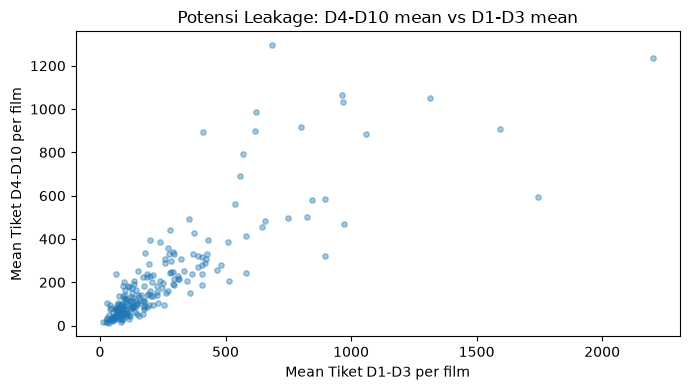

Korelasi All_mean vs D1_3_mean: 0.874
Korelasi All_mean vs D4_10_mean: 0.965

⚠️  Jika korelasi tinggi, fitur all-train mean tidak langsung bocor target, tapi sebaiknya hitung statistik film hanya dari D1-D3 saja (aman).
Rekomendasi: gunakan statistik film berbasis D1-D3 saja saat feature engineering.


<string>:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


In [18]:
# Q14 – Leakage risk: film-level stats computed from full train
# Leakage terjadi jika D4-D10 dari window validasi ikut masuk ke mean film.
# Di sini kita ukur: seberapa besar konstribusi D4-D10 terhadap mean film global.

train_l = dfs['train'].copy()
train_l['date_show'] = pd.to_datetime(train_l['date_show'])
train_l = train_l.sort_values(['movie_title','cinema_ids','date_show'])
train_l['day_idx'] = train_l.groupby(['movie_title','cinema_ids']).cumcount() + 1

d1_3 = train_l[train_l['day_idx'] <= 3].groupby('movie_title')['total_ticket'].mean()
d4_10_mean = train_l[train_l['day_idx'].between(4,10)].groupby('movie_title')['total_ticket'].mean()
all_mean = train_l.groupby('movie_title')['total_ticket'].mean()

leakage_check = pd.DataFrame({'D1_3_mean': d1_3, 'D4_10_mean': d4_10_mean, 'All_mean': all_mean}).dropna()
leakage_check['d4_10_contribution'] = abs(leakage_check['All_mean'] - leakage_check['D1_3_mean'])

print('Korelasi All_mean vs D1_3_mean:', leakage_check[['All_mean','D1_3_mean']].corr().iloc[0,1].round(3))
print('Korelasi All_mean vs D4_10_mean:', leakage_check[['All_mean','D4_10_mean']].corr().iloc[0,1].round(3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(leakage_check['D1_3_mean'], leakage_check['D4_10_mean'], alpha=0.4, s=15)
ax.set_xlabel('Mean Tiket D1-D3 per film')
ax.set_ylabel('Mean Tiket D4-D10 per film')
ax.set_title('Potensi Leakage: D4-D10 mean vs D1-D3 mean')
plt.tight_layout()
plt.show()

print('\n⚠️  Jika korelasi tinggi, fitur all-train mean tidak langsung bocor target,'
     ' tapi sebaiknya hitung statistik film hanya dari D1-D3 saja (aman).\n'
     'Rekomendasi: gunakan statistik film berbasis D1-D3 saja saat feature engineering.')


# Data Preparation

## Data Cleaning & Integration

In [19]:
import re

# 1. Regex pembersihan judul film & ekstraksi format bioskop
def clean_movie_title(title):
    return re.sub(r'\s*\((?:IMAX\s*2D|IMAX\s*3D|3D|2D)\)\s*$', '', str(title), flags=re.IGNORECASE).strip()

def extract_format(title):
    t = str(title).upper()
    if 'IMAX 3D' in t: return 'IMAX 3D'
    if 'IMAX 2D' in t: return 'IMAX 2D'
    if 'IMAX' in t: return 'IMAX'
    if '3D' in t: return '3D'
    return 'REGULAR'

# 2. Imputasi nilai hilang & ekstraksi primary genre
dfs['movies']['clean_title'] = dfs['movies']['original_title'].apply(clean_movie_title)
dfs['movies']['age_rating'] = dfs['movies']['age_rating'].fillna('Unknown')
dfs['movies']['primary_genre'] = dfs['movies']['genre'].fillna('Unknown').apply(lambda x: str(x).split(',')[0].strip())
dfs['holidays']['holiday_name'] = dfs['holidays']['holiday_name'].fillna('None')

# Prekomputasi fitur kompetisi (jumlah film aktif per klaster dan per kota)
all_shows = pd.concat([
    dfs['train'][['date_show', 'cinema_ids', 'city_name', 'movie_title']],
    dfs['test'][['date_show', 'cinema_ids', 'city_name', 'movie_title']],
    dfs['test_history'][['date_show', 'cinema_ids', 'city_name', 'movie_title']]
]).drop_duplicates()

cinema_comp = all_shows.groupby(['date_show', 'cinema_ids'])['movie_title'].nunique().rename('cinema_comp_count').reset_index()
city_comp = all_shows.groupby(['date_show', 'city_name'])['movie_title'].nunique().rename('city_comp_count').reset_index()

# 3. Penggabungan data harga tiket, metadata film, dan kompetisi
def merge_metadata(df, is_test=False):
    df_copy = df.copy()
    df_copy['clean_title'] = df_copy['movie_title'].apply(clean_movie_title)
    df_copy['format_type'] = df_copy['movie_title'].apply(extract_format)
    
    # Merge metadata film via clean_title
    df_merged = df_copy.merge(
        dfs['movies'].drop(columns=['original_title']), 
        on='clean_title', 
        how='left'
    )
    df_merged['age_rating'] = df_merged['age_rating'].fillna('Unknown')
    df_merged['primary_genre'] = df_merged['primary_genre'].fillna('Unknown')
    
    # Merge kalender hari libur
    date_col = 'date' if 'date' in df_merged.columns else 'date_show'
    df_merged = df_merged.merge(
        dfs['holidays'], 
        left_on=date_col, 
        right_on='date', 
        how='left'
    )
    if 'date' in df_merged.columns and date_col != 'date':
        df_merged = df_merged.drop(columns=['date'])
        
    def map_price_day(row):
        if row.get('holiday_tipe') == 'holiday':
            return 'Weekend'
        dt = row.get('day_tipe', 'weekday')
        mapping = {'weekday': 'Weekday', 'friday': 'Friday', 'weekend': 'Weekend'}
        return mapping.get(dt, 'Weekday')
        
    df_merged['price_day'] = df_merged.apply(map_price_day, axis=1)
    
    # Merge batas harga tiket
    df_merged = df_merged.merge(
        dfs['ticket_prices'], 
        on=['city_name', 'price_day'], 
        how='left'
    )
    df_merged['ceil'] = df_merged['ceil'].astype(float).fillna(35000.0)
    
    # Merge kepadatan kompetisi
    df_merged = df_merged.merge(cinema_comp, on=['date_show', 'cinema_ids'], how='left')
    df_merged = df_merged.merge(city_comp, on=['date_show', 'city_name'], how='left')
    df_merged['cinema_comp_count'] = df_merged['cinema_comp_count'].fillna(1).astype(int)
    df_merged['city_comp_count'] = df_merged['city_comp_count'].fillna(1).astype(int)
    
    return df_merged

train_merged = merge_metadata(dfs['train'])
test_history_merged = merge_metadata(dfs['test_history'])
test_merged = merge_metadata(dfs['test'], is_test=True)

print(f'Train merged shape: {train_merged.shape}')
print(f'Test merged shape: {test_merged.shape}')


Train merged shape: (138959, 23)
Test merged shape: (72611, 21)


## Sliding Window Construction

In [20]:
from scipy.optimize import curve_fit

# Lookups cepat kalender dan kompetisi
holiday_dict = dfs['holidays'].set_index('date')['holiday_tipe'].to_dict()
day_tipe_dict = dfs['holidays'].set_index('date')['day_tipe'].to_dict()
price_dict = dfs['ticket_prices'].set_index(['city_name', 'price_day'])['ceil'].to_dict()
cinema_comp_dict = cinema_comp.set_index(['date_show', 'cinema_ids'])['cinema_comp_count'].to_dict()
city_comp_dict = city_comp.set_index(['date_show', 'city_name'])['city_comp_count'].to_dict()

def bass_density(t, m, p, q):
    e = np.exp(-(p + q) * t)
    return m * ((p + q) ** 2 / p) * e / (1 + (q / p) * e) ** 2

def fit_film_curve(y3):
    """y3: tiket nasional D1..D3 (3 nilai). Mengembalikan fungsi t -> tiket harian."""
    t = np.array([1., 2., 3.]); y3 = np.asarray(y3, float)
    try:
        popt, _ = curve_fit(
            bass_density, t, y3, p0=[y3.sum() * 3, 0.2, 0.3],
            bounds=([y3.sum(), 0.01, 0.0], [y3.sum() * 50, 1.0, 2.0]), maxfev=5000)
        return lambda tt: bass_density(np.asarray(tt, float), *popt)
    except Exception:
        b = np.log(max(y3[0], 1) / max(y3[2], 1)) / 2   # fallback: peluruhan eksponensial
        return lambda tt: y3[0] * np.exp(-b * (np.asarray(tt, float) - 1))

def fit_exp_curve(y3):
    """Pembanding eksponensial 2-parameter (a, b)."""
    t = np.array([1., 2., 3.]); y3 = np.asarray(y3, float)
    try:
        popt, _ = curve_fit(
            lambda tt, a, b: a * np.exp(-b * (tt - 1)), t, y3,
            p0=[max(y3[0], 1.0), 0.1],
            bounds=([0.0, -2.0], [np.inf, 5.0]), maxfev=5000)
        return lambda tt: popt[0] * np.exp(-popt[1] * (np.asarray(tt, float) - 1))
    except Exception:
        b = np.log(max(y3[0], 1) / max(y3[2], 1)) / 2
        return lambda tt: y3[0] * np.exp(-b * (np.asarray(tt, float) - 1))

def create_sliding_windows(df_train):
    """
    Ekstraksi window D1-D10 berbasis kalender penuh per (movie_title, cinema_ids).
    Menyertakan fitur hist_days, genre, tren operasional, kompetisi, dan rasio kurva nasional (Bass & Exponential).
    """
    records = []
    pair_start = df_train.groupby(['movie_title', 'cinema_ids'])['date_show'].min()
    film_d1_map = pair_start.groupby(level=0).agg(lambda s: s.mode().min())
    train_start, train_end = df_train['date_show'].min(), df_train['date_show'].max()
    numeric_cols = ['total_ticket', 'occupation_rate', 'total_show']

    # Prekomputasi kurva nasional D1-D3 per film (aman dari kebocoran D4-D10)
    nat_tickets = df_train.groupby(['movie_title', 'date_show'])['total_ticket'].sum()
    film_curves = {}
    for movie, film_d1 in film_d1_map.items():
        obs_dates = pd.date_range(start=film_d1, periods=3, freq='D')
        y3 = [float(nat_tickets.get((movie, d), 0.0)) for d in obs_dates]
        mean_y3 = max(np.mean(y3), 1.0)
        film_curves[movie] = {
            'bass_func': fit_film_curve(y3),
            'exp_func': fit_exp_curve(y3),
            'mean_y3': mean_y3
        }

    for (movie, cinema), group in df_train.groupby(['movie_title', 'cinema_ids']):
        film_d1 = film_d1_map[movie]
        if film_d1 <= train_start or film_d1 + pd.Timedelta(days=9) > train_end:
            continue
        
        city = group['city_name'].iloc[0]
        fmt = group['format_type'].iloc[0]
        rating = group['age_rating'].iloc[0] if 'age_rating' in group.columns else 'Unknown'
        genre = group['primary_genre'].iloc[0] if 'primary_genre' in group.columns else 'Unknown'
        clean_t = group['clean_title'].iloc[0] if 'clean_title' in group.columns else movie

        full_dates = pd.date_range(start=film_d1, periods=10, freq='D')
        group_cal = group.set_index('date_show').reindex(full_dates)
        group_cal.index.name = 'date_show'
        for c in numeric_cols:
            group_cal[c] = group_cal[c].fillna(0.0)
        group_cal = group_cal.reset_index()

        obs = group_cal.iloc[0:3]
        target = group_cal.iloc[3:10]

        t1, t2, t3 = float(obs['total_ticket'].iloc[0]), float(obs['total_ticket'].iloc[1]), float(obs['total_ticket'].iloc[2])
        tot_obs = t1 + t2 + t3
        if t3 == 0:
            continue

        scale = max(tot_obs / 3.0, 1.0)
        occ1, occ2, occ3 = float(obs['occupation_rate'].iloc[0]), float(obs['occupation_rate'].iloc[1]), float(obs['occupation_rate'].iloc[2])
        show1, show2, show3 = float(obs['total_show'].iloc[0]), float(obs['total_show'].iloc[1]), float(obs['total_show'].iloc[2])
        hist_days = int(t1 > 0) + int(t2 > 0) + int(t3 > 0)

        curve_info = film_curves[movie]
        fb = curve_info['bass_func']
        fe = curve_info['exp_func']
        mean_y3 = curve_info['mean_y3']

        hist_feats = {
            'movie_title': movie,
            'cinema_ids': cinema,
            'city_name': city,
            'format_type': fmt,
            'age_rating': rating,
            'primary_genre': genre,
            'scale': scale,
            'hist_sum': tot_obs,
            'hist_mean': tot_obs / 3.0,
            'hist_days': hist_days,
            'ticket_d1': t1,
            'ticket_d2': t2,
            'ticket_d3': t3,
            'ratio_d1': t1 / scale,
            'ratio_d2': t2 / scale,
            'ratio_d3': t3 / scale,
            'trend_d2_d1': t2 / max(t1, 1.0),
            'trend_d3_d2': t3 / max(t2, 1.0),
            'trend_d3_d1': t3 / max(t1, 1.0),
            'occ1': occ1, 'occ2': occ2, 'occ3': occ3,
            'hist_mean_occ': (occ1 + occ2 + occ3) / 3.0,
            'occ_decay': occ3 / max(occ1, 0.01),
            'trend_occ_d2_d1': occ2 / max(occ1, 0.01),
            'show1': show1, 'show2': show2, 'show3': show3,
            'hist_mean_show': (show1 + show2 + show3) / 3.0,
            'show_decay': show3 / max(show1, 1.0),
            'trend_show_d2_d1': show2 / max(show1, 1.0),
            'active_days_d1_3': hist_days,
            'hist_first_dow': int(film_d1.dayofweek),
            'hist_last_dow': int((film_d1 + pd.Timedelta(days=2)).dayofweek),
            'clean_title': clean_t,
            'film_d1': film_d1,
        }

        for day_offset in range(7):
            day_num = day_offset + 4
            tgt_row = target.iloc[day_offset]
            tgt_date = tgt_row['date_show']
            row = hist_feats.copy()
            row['day_offset'] = day_offset + 1
            row['target_dow'] = int(tgt_date.dayofweek)
            row['target_is_weekend'] = int(tgt_date.dayofweek in [5, 6])
            row['target_is_friday'] = int(tgt_date.dayofweek == 4)
            hol_tipe = holiday_dict.get(tgt_date, 'normal')
            row['target_is_holiday'] = int(hol_tipe == 'holiday')
            pday = 'Weekend' if hol_tipe == 'holiday' else {'weekday':'Weekday','friday':'Friday','weekend':'Weekend'}.get(day_tipe_dict.get(tgt_date, 'weekday'), 'Weekday')
            row['target_ceil'] = float(price_dict.get((city, pday), 35000.0))
            row['cinema_comp_count'] = int(cinema_comp_dict.get((tgt_date, cinema), 1))
            row['city_comp_count'] = int(city_comp_dict.get((tgt_date, city), 1))
            
            # Rasio kurva nasional D4-D10 terhadap mean(D1-D3)
            row['bass_ratio'] = max(float(fb(day_num) / mean_y3), 0.0)
            row['exp_ratio'] = max(float(fe(day_num) / mean_y3), 0.0)
            
            row['total_ticket'] = float(tgt_row['total_ticket'])
            row['target_ratio'] = float(tgt_row['total_ticket']) / scale
            records.append(row)

    return pd.DataFrame(records)

train_windowed = create_sliding_windows(train_merged)
print(f'Total baris sampel latih terstruktur: {len(train_windowed)}')
print('target_ceil NaN :', train_windowed['target_ceil'].isna().sum())
print('target_ratio==0 :', (train_windowed['target_ratio'] == 0).sum(), f"({(train_windowed['target_ratio'] == 0).mean():.2%})")
train_windowed.head()


Total baris sampel latih terstruktur: 56196
target_ceil NaN : 0
target_ratio==0 : 18370 (32.69%)


<string>:18: OptimizeWarning: Covariance of the parameters could not be estimated


## Restrukturisasi Dataset Uji & Perhitungan Skala Evaluasi

In [21]:
# Ekstraksi fitur observasi D1-D3 dari test_history_merged berbasis kalender
film_d1_test_map = test_history_merged.groupby('movie_title')['date_show'].min()
test_history_sorted = test_history_merged.sort_values(['movie_title', 'cinema_ids', 'date_show'])

# Prekomputasi kurva nasional test
nat_test = test_history_merged.groupby(['movie_title', 'date_show'])['total_ticket'].sum()
film_curves_test = {}
for movie, film_d1 in film_d1_test_map.items():
    obs_dates = pd.date_range(start=film_d1, periods=3, freq='D')
    y3 = [float(nat_test.get((movie, d), 0.0)) for d in obs_dates]
    mean_y3 = max(np.mean(y3), 1.0)
    film_curves_test[movie] = {
        'bass_func': fit_film_curve(y3),
        'exp_func': fit_exp_curve(y3),
        'mean_y3': mean_y3
    }

def extract_test_history_feats(g):
    movie = g.name[0]
    film_d1 = film_d1_test_map[movie]

    obs_dates = pd.date_range(start=film_d1, periods=3, freq='D')
    g_idx = g.set_index('date_show').reindex(obs_dates)

    t1 = float(g_idx['total_ticket'].iloc[0]) if not pd.isna(g_idx['total_ticket'].iloc[0]) else 0.0
    t2 = float(g_idx['total_ticket'].iloc[1]) if not pd.isna(g_idx['total_ticket'].iloc[1]) else 0.0
    t3 = float(g_idx['total_ticket'].iloc[2]) if not pd.isna(g_idx['total_ticket'].iloc[2]) else 0.0

    tot = t1 + t2 + t3
    scale = max(tot / 3.0, 1.0)
    n = int((~g_idx['total_ticket'].isna()).sum())

    occ1 = float(g_idx['occupation_rate'].iloc[0]) if not pd.isna(g_idx['occupation_rate'].iloc[0]) else 0.0
    occ2 = float(g_idx['occupation_rate'].iloc[1]) if not pd.isna(g_idx['occupation_rate'].iloc[1]) else 0.0
    occ3 = float(g_idx['occupation_rate'].iloc[2]) if not pd.isna(g_idx['occupation_rate'].iloc[2]) else 0.0

    s1 = float(g_idx['total_show'].iloc[0]) if not pd.isna(g_idx['total_show'].iloc[0]) else 0.0
    s2 = float(g_idx['total_show'].iloc[1]) if not pd.isna(g_idx['total_show'].iloc[1]) else 0.0
    s3 = float(g_idx['total_show'].iloc[2]) if not pd.isna(g_idx['total_show'].iloc[2]) else 0.0

    return pd.Series({
        'hist_days': n,
        'hist_sum': tot,
        'hist_mean': tot / 3.0,
        'scale': scale,
        'ticket_d1': t1,
        'ticket_d2': t2,
        'ticket_d3': t3,
        'ratio_d1': t1 / scale,
        'ratio_d2': t2 / scale,
        'ratio_d3': t3 / scale,
        'trend_d2_d1': t2 / max(t1, 1.0),
        'trend_d3_d2': t3 / max(t2, 1.0),
        'trend_d3_d1': t3 / max(t1, 1.0),
        'occ1': occ1, 'occ2': occ2, 'occ3': occ3,
        'hist_mean_occ': (occ1 + occ2 + occ3) / 3.0,
        'occ_decay': occ3 / max(occ1, 0.01),
        'trend_occ_d2_d1': occ2 / max(occ1, 0.01),
        'show1': s1, 'show2': s2, 'show3': s3,
        'hist_mean_show': (s1 + s2 + s3) / 3.0,
        'show_decay': s3 / max(s1, 1.0),
        'trend_show_d2_d1': s2 / max(s1, 1.0),
        'active_days_d1_3': int(t1 > 0) + int(t2 > 0) + int(t3 > 0),
        'hist_first_dow': int(film_d1.dayofweek),
        'hist_last_dow': int((film_d1 + pd.Timedelta(days=2)).dayofweek),
    })

test_obs = (
    test_history_sorted
    .groupby(['movie_title', 'cinema_ids'])
    .apply(extract_test_history_feats, include_groups=False)
    .reset_index()
)

test_prepared = test_merged.merge(test_obs, on=['movie_title', 'cinema_ids'], how='left')
test_prepared['date_show'] = pd.to_datetime(test_prepared['date_show'])
test_prepared['day_offset'] = test_prepared.groupby(['movie_title', 'cinema_ids'])['date_show'].rank(method='first').astype(int)
test_prepared['target_dow'] = test_prepared['date_show'].dt.dayofweek
test_prepared['target_is_weekend'] = test_prepared['target_dow'].isin([5, 6]).astype(int)
test_prepared['target_is_friday'] = (test_prepared['target_dow'] == 4).astype(int)
test_prepared['target_is_holiday'] = (test_prepared['holiday_tipe'] == 'holiday').astype(int)
test_prepared['target_ceil'] = test_prepared['ceil'].astype(float)
test_prepared['cinema_comp_count'] = test_prepared['cinema_comp_count'].fillna(1).astype(int)
test_prepared['city_comp_count'] = test_prepared['city_comp_count'].fillna(1).astype(int)
test_prepared['scale'] = test_prepared['scale'].fillna(1.0)
test_prepared['primary_genre'] = test_prepared['primary_genre'].fillna('Unknown')

# Rasio prediksi Bass dan Exp kurva nasional
test_prepared['bass_ratio'] = test_prepared.apply(
    lambda r: max(float(film_curves_test[r['movie_title']]['bass_func'](r['day_offset'] + 3) / film_curves_test[r['movie_title']]['mean_y3']), 0.0),
    axis=1
)
test_prepared['exp_ratio'] = test_prepared.apply(
    lambda r: max(float(film_curves_test[r['movie_title']]['exp_func'](r['day_offset'] + 3) / film_curves_test[r['movie_title']]['mean_y3']), 0.0),
    axis=1
)

print(f'Test prepared shape: {test_prepared.shape}')
assert test_prepared['day_offset'].between(1, 7).all(), 'day_offset di luar 1..7'
assert (test_prepared.groupby(['movie_title', 'cinema_ids']).size() == 7).all(), 'ada pasangan test != 7 hari'
print('Kolom fitur test dengan NaN:', test_prepared[['scale','hist_mean_occ','hist_mean_show','target_ceil','bass_ratio','exp_ratio']].isna().sum().to_dict())
test_prepared.head()


Test prepared shape: (72611, 57)
Kolom fitur test dengan NaN: {'scale': 0, 'hist_mean_occ': 0, 'hist_mean_show': 0, 'target_ceil': 0, 'bass_ratio': 0, 'exp_ratio': 0}


<string>:18: OptimizeWarning: Covariance of the parameters could not be estimated


# Modeling

In [22]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error

def mase_score(y_true, y_pred, scale):
    return mean_absolute_error(y_true / scale, y_pred / scale)

# Fitur Agregat Film (Volume & Trend Nasional) & Klaster Bioskop (Point 2)
for df in [train_windowed, test_prepared]:
    pair_win = df.drop_duplicates(["movie_title", "cinema_ids"])
    mv = pair_win.groupby("movie_title")[["ticket_d1", "ticket_d2", "ticket_d3"]].sum().add_prefix("mv_")
    mv["mv_clusters"] = pair_win.groupby("movie_title")["ticket_d3"].apply(lambda s: (s > 0).sum())
    mv["mv_trend"] = (mv["mv_ticket_d3"] + 1) / (mv["mv_ticket_d1"] + 1)
    for col in mv.columns:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)
    df_merged = df.merge(mv, on="movie_title", how="left")
    for col in mv.columns:
        df[col] = df_merged[col].values
    tot_pair = df["ticket_d1"] + df["ticket_d2"] + df["ticket_d3"]
    tot_mv = df["mv_ticket_d1"] + df["mv_ticket_d2"] + df["mv_ticket_d3"]
    df["pair_share"] = (tot_pair / tot_mv.replace(0, np.nan)).fillna(0).values

all_pairs = pd.concat([
    train_windowed[["cinema_ids", "movie_title", "scale"]].drop_duplicates(["cinema_ids", "movie_title"]),
    test_prepared[["cinema_ids", "movie_title", "scale"]].drop_duplicates(["cinema_ids", "movie_title"])
], ignore_index=True)
cl_feats = all_pairs.groupby("cinema_ids").agg(cl_scale=("scale", "mean"), cl_movies=("movie_title", "nunique"))

for df in [train_windowed, test_prepared]:
    for col in ["cl_scale", "cl_movies"]:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)
    df_merged = df.merge(cl_feats, on="cinema_ids", how="left")
    df["cl_scale"] = df_merged["cl_scale"].values
    df["cl_movies"] = df_merged["cl_movies"].values

feature_cols = [
    "scale", "hist_sum", "hist_mean", "hist_days",
    "ticket_d1", "ticket_d2", "ticket_d3",
    "ratio_d1", "ratio_d2", "ratio_d3", 
    "trend_d2_d1", "trend_d3_d2", "trend_d3_d1",
    "occ1", "occ2", "occ3", "hist_mean_occ", "occ_decay", "trend_occ_d2_d1",
    "show1", "show2", "show3", "hist_mean_show", "show_decay", "trend_show_d2_d1",
    "active_days_d1_3", "hist_first_dow", "hist_last_dow",
    "day_offset", "target_dow", "target_is_weekend", "target_is_friday",
    "target_is_holiday", "target_ceil",
    "city_name", "format_type", "age_rating", "primary_genre",
    "mv_ticket_d1", "mv_ticket_d2", "mv_ticket_d3", "mv_clusters", "mv_trend", "pair_share",
    "cl_scale", "cl_movies"
]

cat_cols = ["target_dow", "hist_first_dow", "hist_last_dow", "city_name", "format_type", "age_rating", "primary_genre"]

def _norm(s):
    return s.astype(str).str.replace(r"\.0$", "", regex=True)

for col in cat_cols:
    cats = sorted(set(_norm(train_windowed[col])) | set(_norm(test_prepared[col])))
    train_windowed[col] = pd.Categorical(_norm(train_windowed[col]), categories=cats)
    test_prepared[col] = pd.Categorical(_norm(test_prepared[col]), categories=cats)

X = train_windowed[feature_cols]
y = train_windowed["target_ratio"].values
groups = train_windowed["clean_title"] if "clean_title" in train_windowed.columns else train_windowed["movie_title"]
scales = train_windowed["scale"].values

gkf = GroupKFold(n_splits=5)
print(f"Jumlah sampel latih: {len(X)} | Jumlah fitur: {len(feature_cols)}")

results = {}


Jumlah sampel latih: 56196 | Jumlah fitur: 40


In [23]:
print(">>> Training & Evaluating LightGBM (Ratio Formulation)")
oof_pred_ratios = np.zeros(len(train_windowed))
trained_models = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    X_tr, y_tr = X.iloc[train_idx], y[train_idx]
    X_va, y_va = X.iloc[val_idx], y[val_idx]
    
    model = lgb.LGBMRegressor(
        objective="regression_l1",
        n_estimators=150,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=SEED + fold,
        verbose=-1
    )
    model.fit(X_tr, y_tr)
    
    pred_ratio = np.clip(model.predict(X_va), 0.0, None)
    oof_pred_ratios[val_idx] = pred_ratio
    trained_models.append(model)
    
    pred_tickets = pred_ratio * scales[val_idx]
    fold_mase = mase_score(train_windowed["total_ticket"].values[val_idx], pred_tickets, scales[val_idx])
    print(f"Fold {fold+1} MASE: {fold_mase:.4f}")

oof_pred_tickets = oof_pred_ratios * scales
overall_mase = mase_score(train_windowed["total_ticket"].values, oof_pred_tickets, scales)
results["LightGBM"] = {"mase": overall_mase, "oof": oof_pred_tickets}
print(f">>> Overall OOF MASE LightGBM: {overall_mase:.4f}")


>>> Training & Evaluating LightGBM (Ratio Formulation)
Fold 1 MASE: 0.3907
Fold 2 MASE: 0.3710
Fold 3 MASE: 0.3573
Fold 4 MASE: 0.3738
Fold 5 MASE: 0.4891
>>> Overall OOF MASE LightGBM: 0.3964


/mnt/c/Users/ASUS/Downloads/New folder/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/mnt/c/Users/ASUS/Downloads/New folder/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/mnt/c/Users/ASUS/Downloads/New folder/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/mnt/c/Users/ASUS/Downloads/New folder/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is dep

In [24]:
# CatBoost ratio regressor
from catboost import CatBoostRegressor

print(">>> Training & Evaluating CatBoost (Ratio Formulation)")
oof_cat_ratios = np.zeros(len(train_windowed))
cat_models = []

X_cat = X.copy()
for col in cat_cols:
    X_cat[col] = X_cat[col].astype(str)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_cat, y, groups)):
    X_tr, y_tr = X_cat.iloc[train_idx], y[train_idx]
    X_va, y_va = X_cat.iloc[val_idx], y[val_idx]

    model = CatBoostRegressor(
        loss_function="MAE",
        iterations=500,
        learning_rate=0.04,
        depth=6,
        cat_features=cat_cols,
        random_seed=SEED + fold,
        verbose=0
    )
    model.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),
        early_stopping_rounds=40,
        verbose=False
    )

    pred_ratio = np.clip(model.predict(X_va), 0.0, None)
    oof_cat_ratios[val_idx] = pred_ratio
    cat_models.append(model)

oof_cat_tickets = oof_cat_ratios * scales
mase_cat = mase_score(train_windowed["total_ticket"].values, oof_cat_tickets, scales)
results["CatBoost"] = {"mase": mase_cat, "oof": oof_cat_tickets}
print(f"Overall OOF MASE CatBoost: {mase_cat:.4f}")

>>> Training & Evaluating CatBoost (Ratio Formulation)
Overall OOF MASE CatBoost: 0.3948


In [25]:
# LightGBM ratio regressor (Variant 2)
print(">>> Training & Evaluating LightGBM Variant 2")
oof_lgb2_ratios = np.zeros(len(train_windowed))
lgb2_models = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    X_tr, y_tr = X.iloc[train_idx], y[train_idx]
    X_va, y_va = X.iloc[val_idx], y[val_idx]

    model = lgb.LGBMRegressor(
        objective="regression_l1",
        n_estimators=500,
        learning_rate=0.02,
        num_leaves=63,
        min_child_samples=25,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=SEED + 100 + fold,
        verbose=-1
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )

    pred_ratio = np.clip(model.predict(X_va), 0.0, None)
    oof_lgb2_ratios[val_idx] = pred_ratio
    lgb2_models.append(model)

oof_lgb2_tickets = oof_lgb2_ratios * scales
mase_lgb2 = mase_score(train_windowed["total_ticket"].values, oof_lgb2_tickets, scales)
results["LightGBM_v2"] = {"mase": mase_lgb2, "oof": oof_lgb2_tickets}
print(f"Overall OOF MASE LightGBM v2: {mase_lgb2:.4f}")

>>> Training & Evaluating LightGBM Variant 2
Overall OOF MASE LightGBM v2: 0.3988


/mnt/c/Users/ASUS/Downloads/New folder/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/mnt/c/Users/ASUS/Downloads/New folder/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/mnt/c/Users/ASUS/Downloads/New folder/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/mnt/c/Users/ASUS/Downloads/New folder/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is dep

# Evaluasi

In [26]:
from scipy.optimize import minimize

# Baseline pembanding kurva (zero-shot) pada baris OOF identik
oof_bass_tickets = train_windowed["bass_ratio"].values * scales
oof_exp_tickets = train_windowed["exp_ratio"].values * scales
oof_a_tickets = 1.0 * scales

results["Baseline A (Rasio=1)"] = {
    "mase": mase_score(train_windowed["total_ticket"].values, oof_a_tickets, scales),
    "oof": oof_a_tickets
}
results["Baseline Exp 2-Param"] = {
    "mase": mase_score(train_windowed["total_ticket"].values, oof_exp_tickets, scales),
    "oof": oof_exp_tickets
}
results["Bass Diffusion (Zero-shot)"] = {
    "mase": mase_score(train_windowed["total_ticket"].values, oof_bass_tickets, scales),
    "oof": oof_bass_tickets
}

# Optimasi bobot blend berbasis OOF MASE
preds = np.column_stack([
    results["LightGBM"]["oof"] / scales, 
    results["CatBoost"]["oof"] / scales, 
    results["LightGBM_v2"]["oof"] / scales
])
y_true_ratio = y

def blend_loss(w):
    w = np.array(w)
    w = w / np.sum(w)
    return mean_absolute_error(y_true_ratio, np.sum(preds * w, axis=1))

opt_res = minimize(blend_loss, [1/3, 1/3, 1/3], bounds=[(0, 1), (0, 1), (0, 1)], method="SLSQP")
opt_weights = opt_res.x / np.sum(opt_res.x)

oof_blend_opt = (preds @ opt_weights) * scales
results["Blend (optimal)"] = {
    "mase": mase_score(train_windowed["total_ticket"].values, oof_blend_opt, scales),
    "oof": oof_blend_opt,
    "weights": opt_weights
}

comparison_df = pd.DataFrame([
    {"Model / Baseline": name, "Overall OOF MASE": res["mase"]} 
    for name, res in results.items()
]).sort_values("Overall OOF MASE").reset_index(drop=True)

print(">>> Model Benchmark Summary (OOF GroupKFold - Identical Subset)")
print(comparison_df)
print(f"Optimal Ensemble Weights: LightGBM={opt_weights[0]:.4f}, CatBoost={opt_weights[1]:.4f}, LightGBM_v2={opt_weights[2]:.4f}")


>>> Model Benchmark Summary (OOF GroupKFold - Identical Subset)
             Model / Baseline  Overall OOF MASE
0             Blend (optimal)          0.392821
1                    CatBoost          0.394833
2                    LightGBM          0.396387
3                 LightGBM_v2          0.398844
4  Bass Diffusion (Zero-shot)          0.660916
5        Baseline A (Rasio=1)          0.754621
6        Baseline Exp 2-Param          4.360407
Optimal Ensemble Weights: LightGBM=0.2583, CatBoost=0.6136, LightGBM_v2=0.1281


## Validasi Berbasis Waktu & Analisis Mendalam Fold 3 [PATCH]

Test berada di periode setelah train, jadi validasi tambahan: latih pada film yang tayang lebih awal, validasi pada ~20% film terakhir (dengan *purge* 10 hari agar jendela tidak tumpang tindih). Selain itu, dilakukan diagnosis terhadap Fold 3 yang memiliki varians error tertinggi pada cross-validation.


In [27]:
# [PATCH] Holdout berbasis waktu + Evaluasi Tersegmentasi (hist_days, skala, genre)
cut = train_windowed["film_d1"].quantile(0.8)
tr_m = (train_windowed["film_d1"] + pd.Timedelta(days=10)) <= cut   # purge: jendela train selesai sebelum validasi
va_m = train_windowed["film_d1"] >= cut
print(f"Holdout waktu | train: {tr_m.sum()} baris | valid: {va_m.sum()} baris | cut D1 >= {cut.date()}")

def _daytype(df):
    return np.where(df["target_is_holiday"] == 1, "H",
           np.where(df["target_is_weekend"] == 1, "W",
           np.where(df["target_is_friday"] == 1, "F", "D")))

tw = train_windowed.copy()
tw["dtype"] = _daytype(tw)
tr_df, va_df = tw[tr_m], tw[va_m]
y_va_t = va_df["total_ticket"].values
sc_va = va_df["scale"].values

# Baseline A, Exp, Bass, & B
mase_A = mase_score(y_va_t, 1.0 * sc_va, sc_va)
mase_exp_holdout = mase_score(y_va_t, va_df["exp_ratio"].values * sc_va, sc_va)
mase_bass_holdout = mase_score(y_va_t, va_df["bass_ratio"].values * sc_va, sc_va)

med = tr_df.groupby(["day_offset", "dtype"])["target_ratio"].median()
predB = va_df.set_index(["day_offset", "dtype"]).index.map(med).to_numpy(dtype=float)
predB = np.nan_to_num(predB, nan=1.0)
mase_B = mase_score(y_va_t, predB * sc_va, sc_va)

m_t = lgb.LGBMRegressor(objective="regression_l1", n_estimators=400, learning_rate=0.03, num_leaves=31,
                        min_child_samples=20, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                        random_state=SEED, verbose=-1)
m_t.fit(X[tr_m.values], y[tr_m.values])
pred_t = np.clip(m_t.predict(X[va_m.values]), 0.0, None)
mase_L = mase_score(y_va_t, pred_t * sc_va, sc_va)

print(f"Baseline A (rasio=1)            : {mase_A:.4f}")
print(f"Baseline B (hari x offset)      : {mase_B:.4f}")
print(f"Baseline Exp 2-Param (Holdout)  : {mase_exp_holdout:.4f}")
print(f"Bass Diffusion (Holdout)        : {mase_bass_holdout:.4f}")
print(f"LightGBM Full Feat (Holdout)    : {mase_L:.4f}")

# Evaluasi per Segmen (hist_days, kelas skala, genre) pada OOF
print()
print("="*60)
print(">>> EVALUASI MASE TERSEGMENTASI (GroupKFold OOF)")
print("="*60)

eval_df = train_windowed.copy()
eval_df["pred_ratio_lgb"] = results["LightGBM"]["oof"] / scales
eval_df["pred_ratio_blend"] = results["Blend (optimal)"]["oof"] / scales
eval_df["mase_bass"] = np.abs(eval_df["target_ratio"] - eval_df["bass_ratio"])
eval_df["mase_exp"] = np.abs(eval_df["target_ratio"] - eval_df["exp_ratio"])
eval_df["mase_lgb"] = np.abs(eval_df["target_ratio"] - eval_df["pred_ratio_lgb"])
eval_df["mase_blend"] = np.abs(eval_df["target_ratio"] - eval_df["pred_ratio_blend"])
eval_df["scale_bin"] = pd.qcut(eval_df["scale"], q=4, labels=["Q1 (Kecil)", "Q2 (Menengah Bawah)", "Q3 (Menengah Atas)", "Q4 (Besar)"])

print("1. Segmen: hist_days (Jumlah Hari Observasi D1-D3 Aktif):")
seg_hist = eval_df.groupby("hist_days")[["mase_exp", "mase_bass", "mase_lgb", "mase_blend"]].mean()
print(seg_hist)

print("2. Segmen: Kelas Skala Penjualan (Kuartil Skala):")
seg_scale = eval_df.groupby("scale_bin", observed=False)[["mase_exp", "mase_bass", "mase_lgb", "mase_blend"]].mean()
print(seg_scale)

print("3. Segmen: Top 5 Genre Film:")
top5_genres = eval_df["primary_genre"].value_counts().head(5).index
seg_genre = eval_df[eval_df["primary_genre"].isin(top5_genres)].groupby("primary_genre")[["mase_exp", "mase_bass", "mase_lgb", "mase_blend"]].mean()
print(seg_genre)


Holdout waktu | train: 40950 baris | valid: 12152 baris | cut D1 >= 2025-08-21
Baseline A (rasio=1)            : 0.7746
Baseline B (hari x offset)      : 0.4360
Baseline Exp 2-Param (Holdout)  : 1.7786
Bass Diffusion (Holdout)        : 0.7016
LightGBM Full Feat (Holdout)    : 0.4170

>>> EVALUASI MASE TERSEGMENTASI (GroupKFold OOF)
1. Segmen: hist_days (Jumlah Hari Observasi D1-D3 Aktif):
            mase_exp  mase_bass  mase_lgb  mase_blend
hist_days                                            
1          16.696863   3.084225  2.845464    2.859932
2          11.872747   0.806254  0.649799    0.646187
3           3.443953   0.589601  0.315608    0.311604
2. Segmen: Kelas Skala Penjualan (Kuartil Skala):
                     mase_exp  mase_bass  mase_lgb  mase_blend
scale_bin                                                     
Q1 (Kecil)           4.868902   0.745220  0.585714    0.582048
Q2 (Menengah Bawah)  4.937051   0.580008  0.363894    0.362445
Q3 (Menengah Atas)   4.760565   0.64

# Submission

In [ ]:
# Latih model final pada 100% data train (Point 3)
final_params = dict(
    objective="regression_l1",
    n_estimators=150,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=SEED,
    verbose=-1
)
final_model = lgb.LGBMRegressor(**final_params).fit(X, y)
pred_ratios = np.clip(final_model.predict(test_prepared[feature_cols]), 0.0, None)
test_prepared["predicted_ratio"] = pred_ratios

# Post-processing musiman: Lebaran (2.0x) & Libur Sekolah (1.25x)
SCHOOL_HOLIDAYS = [
    ("2025-03-25", "2025-04-07"), ("2025-06-28", "2025-07-13"), ("2025-12-22", "2026-01-04"),
    ("2026-02-16", "2026-02-20"), ("2026-03-16", "2026-03-27"),
]
SCHOOL_DAYS = pd.DatetimeIndex(np.concatenate([pd.date_range(a, b) for a, b in SCHOOL_HOLIDAYS]))
RAMADAN_START, LEBARAN_START = pd.Timestamp("2026-02-19"), pd.Timestamp("2026-03-20")

d1 = test_prepared["movie_title"].map(film_d1_test_map)
d13 = [d1 + pd.Timedelta(days=k) for k in range(3)]
d13_ramadan = np.any([(d >= RAMADAN_START) & (d < LEBARAN_START) for d in d13], axis=0)
lebaran = d13_ramadan & (test_prepared["date_show"] >= LEBARAN_START)
school = np.all([d.isin(SCHOOL_DAYS) for d in d13], axis=0) & test_prepared["date_show"].isin(SCHOOL_DAYS)
test_prepared["season_factor"] = np.select([lebaran, school], [2.0, 1.25], 1.0)

test_prepared["total_ticket"] = np.clip(pred_ratios * test_prepared["scale"], 0.0, None) * test_prepared["season_factor"]
print("Distribusi faktor musiman:", test_prepared["season_factor"].value_counts())


In [29]:
# Format akhir sesuai kebutuhan sample_submission.csv
submission = test_prepared[["id", "total_ticket"]].copy()
submission["id"] = submission["id"].astype(int)
submission = submission.sort_values("id").reset_index(drop=True)

# Verifikasi integritas data penyerahan
assert len(submission) == 72611, f"[Peringatan] Jumlah baris tidak sesuai: {len(submission)}"
assert submission["total_ticket"].isnull().sum() == 0, "[Peringatan] Terdapat nilai hilang pada prediksi"

submission.to_csv("submission_baseline_v2.csv", index=False)
print("File submission_baseline.csv berhasil disimpan.")
print("Bentuk dataset:", submission.shape)
print(submission.head(10))


File submission_baseline.csv berhasil disimpan.
Bentuk dataset: (72611, 2)
   id  total_ticket
0   1     24.262374
1   2     17.586444
2   3      4.066208
3   4      2.301290
4   5      3.033807
5   6      3.361737
6   7      3.414379
7   8     74.951560
8   9     63.038456
9  10     38.435611
